### train the linear TAE model by single pair of 0.1tau time-lagged configurations at T=0.47

In [1]:
import numpy as np
import torch
import random
import os
from tae import time_lagged_autoencoder


pastdata = np.load("T=0.47_time=0.0tau_radial_gaussian_features.npy", allow_pickle=True)[:3277][:, 0:200]
futuredata = np.load("T=0.47_time=0.1tau_radial_gaussian_features.npy", allow_pickle=True)[:3277][:, 0:200]
propensity = np.loadtxt("./T=0.47_select_time_propensities_isoconfigurational_results.txt")
time = propensity[0]; propensity = propensity[1:]

pastdata = torch.from_numpy(pastdata); futuredata = torch.from_numpy(futuredata)
traindata = torch.utils.data.TensorDataset(pastdata, futuredata)
train_loader = torch.utils.data.DataLoader(dataset=traindata, batch_size=int(len(traindata)), shuffle=False, num_workers=1)
validate_loader = torch.utils.data.DataLoader(dataset=traindata, batch_size=int(200), shuffle=False, num_workers=1)

tae = time_lagged_autoencoder(input_dim=200, latent_dim=2, hidden_dim=1000, encoder=None, decoder=None, device=torch.device("cpu"), 
                 learning_rate=8e-4, optimizer=None, regularization='None', weight_decay=1e-5, schedular=None)
tae.fit(train_loader=train_loader, num_epochs=120, validation_loader=None, print_log=True, shrinkage=True, eps=1e-5)
project_config = tae.transform(pastdata)

==>epoch=0, training process=0.83%, the loss on training dataset=0.66607;
==>epoch=1, training process=1.67%, the loss on training dataset=0.65759;
==>epoch=2, training process=2.50%, the loss on training dataset=0.65889;
==>epoch=3, training process=3.33%, the loss on training dataset=0.65924;
==>epoch=4, training process=4.17%, the loss on training dataset=0.65325;
==>epoch=5, training process=5.00%, the loss on training dataset=0.64717;
==>epoch=6, training process=5.83%, the loss on training dataset=0.64546;
==>epoch=7, training process=6.67%, the loss on training dataset=0.64636;
==>epoch=8, training process=7.50%, the loss on training dataset=0.64575;
==>epoch=9, training process=8.33%, the loss on training dataset=0.64327;
==>epoch=10, training process=9.17%, the loss on training dataset=0.64109;
==>epoch=11, training process=10.00%, the loss on training dataset=0.64052;
==>epoch=12, training process=10.83%, the loss on training dataset=0.64079;
==>epoch=13, training process=11.

==>epoch=108, training process=90.83%, the loss on training dataset=0.63332;
==>epoch=109, training process=91.67%, the loss on training dataset=0.63331;
==>epoch=110, training process=92.50%, the loss on training dataset=0.63330;
==>epoch=111, training process=93.33%, the loss on training dataset=0.63328;
==>epoch=112, training process=94.17%, the loss on training dataset=0.63327;
==>epoch=113, training process=95.00%, the loss on training dataset=0.63326;
==>epoch=114, training process=95.83%, the loss on training dataset=0.63324;
==>epoch=115, training process=96.67%, the loss on training dataset=0.63323;
==>epoch=116, training process=97.50%, the loss on training dataset=0.63322;
==>epoch=117, training process=98.33%, the loss on training dataset=0.63320;
==>epoch=118, training process=99.17%, the loss on training dataset=0.63319;
==>epoch=119, training process=100.00%, the loss on training dataset=0.63318;


### correlate the leading order parameters with propensities at different time

In [2]:
from scipy import stats

correlation1 = []; correlation2 = []; 
for t in range(len(time)):
    correlation1.append(stats.pearsonr(project_config[:, 0], propensity[:, t]).statistic)
    correlation2.append(stats.pearsonr(project_config[:, 1], propensity[:, t]).statistic)
correlation1 = np.abs(np.array(correlation1)); correlation2 = np.abs(np.array(correlation2))

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


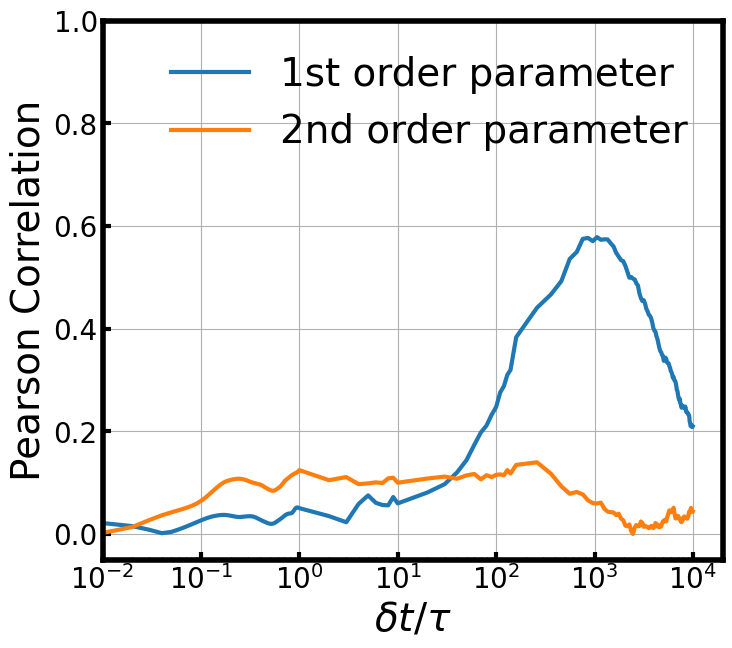

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 7))     
plt.plot(time, correlation1, label="1st order parameter", linewidth=3.0)
plt.plot(time, correlation2, label="2nd order parameter", linewidth=3.0)
plt.tick_params(which='major', width=3, direction='in', labelsize=15, length=6)
plt.tick_params(which='minor', width=1, direction='in', length=2)
ax.set_xscale("log")
plt.ylim(-0.05, 1.0)
plt.xlim(1e-2, 2e4)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['bottom'].set_linewidth(4.0)
ax.spines['left'].set_linewidth(4.0)
ax.spines['top'].set_linewidth(4.0)
ax.spines['right'].set_linewidth(4.0)
legend_font = {'family':"Times New Roman", 'size':28}
plt.legend(loc='upper right', prop=legend_font, ncol=1, frameon=False)
ax.xaxis.get_offset_text().set_fontsize(19)
plt.ylabel("Pearson Correlation", fontdict={'size':28})
plt.xlabel("$\delta t/ \\tau$", fontdict={'size':28})
plt.grid()

### visualize the order parameters and color the embeded particles by propensties at 960 tau

Text(0, 0.5, 'Order Parameter 2')

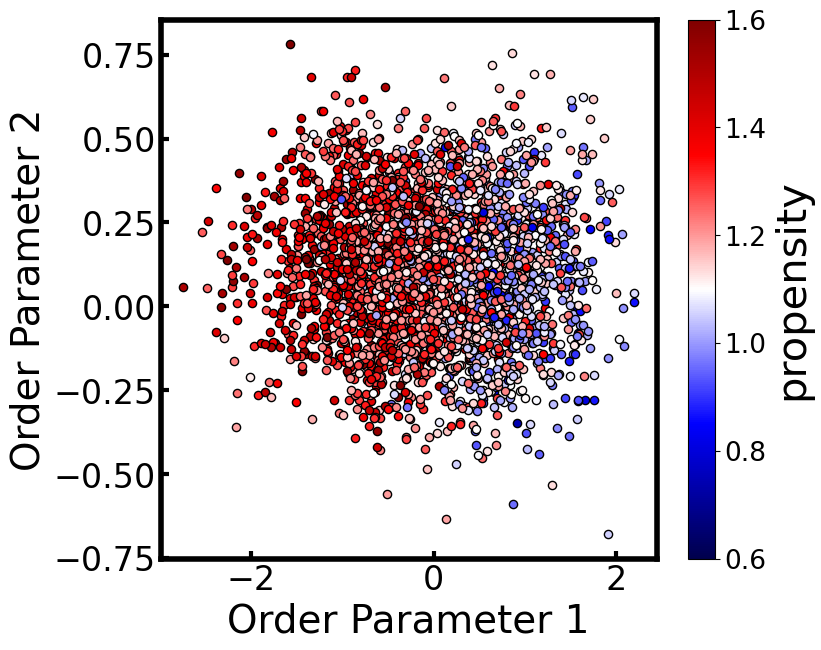

In [4]:
tau = 130
cm = plt.cm.get_cmap("seismic")
z = np.linspace(0, 1, 20)
min_propensity = 0.6
max_propensity = 1.6


fig, ax = plt.subplots(figsize=(8, 7)) 
for i in range(3277):
    plt.scatter(project_config[i, 0], project_config[i,1], c=propensity[i, tau], vmin=min_propensity, vmax=max_propensity, s=35, cmap=cm, edgecolors='black')
cb = plt.colorbar()
cb.ax.tick_params(labelsize=19)
cb.set_label('propensity',fontsize=30)
ax.spines['bottom'].set_linewidth(4.0)
ax.spines['left'].set_linewidth(4.0)
ax.spines['top'].set_linewidth(4.0)
ax.spines['right'].set_linewidth(4.0)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tick_params(which='major', width=3, direction='in', labelsize=24, length=6)
plt.tick_params(which='minor', width=1, direction='in', length=0)
plt.xlabel("Order Parameter 1", fontdict={'size':28})
plt.ylabel("Order Parameter 2", fontdict={'size':28})

### do the Gaussian Mixture clustering in the order parameter space

In [5]:
from sklearn.mixture import GaussianMixture

relation = 0
for seed in range(300):
    gm = GaussianMixture(n_components=2, random_state=seed).fit(project_config)
    likelihood = gm.predict_proba(project_config)
    a = stats.pearsonr(likelihood[:, 1], propensity[:, 130]).statistic
    if a > relation:
        relation = a
        print("seed = {}, the correlation is maximized to: {};".format(seed, a))

seed = 1, the correlation is maximized to: 0.5653992882981654;
seed = 3, the correlation is maximized to: 0.5654681514753835;
seed = 6, the correlation is maximized to: 0.5661720246244205;
